## Análise exploratória: BR-101 Curitiba–Florianópolis

**Projeto:** Uma estudo preditivo sobre o impacto que a ViaMar irá causar na BR101 entre Joinville e Florianópolis.

**Autores:** 

**Fonte dos dados:** Polícia Rodoviária Federal (PRF), dados abertos


### 1 - Contexto

A futura rodovia **ViaMar** ligará Joinville a Florianópolis, em paralelo ao trecho da **BR-101**
que hoje faz essa ligação (municípios de Garuvá a Palhoça, aproximadamente do km 0 ao km 215 da
BR-101/SC).

### 2 - Script

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

DADOS_DIR = Path.cwd().parent / "dados"
COR_DESTAQUE = "#c0392b"
COR_BASE = "#2a78d6"

CORREDOR_MUNICIPIOS = [
    "GARUVA", "JOINVILLE", "ARAQUARI", "BARRA VELHA", "BALNEARIO PICARRAS",
    "PENHA", "NAVEGANTES", "ITAJAI", "CAMBORIU", "BALNEARIO CAMBORIU",
    "ITAPEMA", "PORTO BELO", "TIJUCAS", "GOVERNADOR CELSO RAMOS", "BIGUACU",
    "SAO JOSE", "FLORIANOPOLIS", "PALHOCA",
]
MUNICIPIO_LABEL = {
    "GARUVA": "Garuvá", "JOINVILLE": "Joinville", "ARAQUARI": "Araquari",
    "BARRA VELHA": "Barra Velha", "BALNEARIO PICARRAS": "Bal. Piçarras",
    "PENHA": "Penha", "NAVEGANTES": "Navegantes", "ITAJAI": "Itajaí",
    "CAMBORIU": "Camboriú", "BALNEARIO CAMBORIU": "Bal. Camboriú",
    "ITAPEMA": "Itapema", "PORTO BELO": "Porto Belo", "TIJUCAS": "Tijucas",
    "GOVERNADOR CELSO RAMOS": "Gov. Celso Ramos", "BIGUACU": "Biguaçu",
    "SAO JOSE": "São José", "FLORIANOPOLIS": "Florianópolis", "PALHOCA": "Palhoça",
}
CORREDOR_KM_EXTENSAO = 215
RESTO_KM_EXTENSAO = 463 - CORREDOR_KM_EXTENSAO


def carregar_csv(nome_arquivo, coluna_data, formato_data):
    df = pd.read_csv(DADOS_DIR / nome_arquivo, sep=";", encoding="latin1", low_memory=False)
    df[coluna_data] = pd.to_datetime(df[coluna_data], format=formato_data, errors="coerce")
    if "km" in df.columns:
        df["km_num"] = pd.to_numeric(df["km"].astype(str).str.replace(",", ".", regex=False), errors="coerce")
    return df


dt = carregar_csv("datatran2026.csv", "data_inversa", "%d/%m/%Y")   # 1 linha = 1 acidente
ac = carregar_csv("acidentes2026.csv", "data_inversa", "%Y-%m-%d")  # 1 linha = 1 pessoa envolvida

br101_sc = dt[(dt["br"] == 101) & (dt["uf"] == "SC")].copy()

corredor = br101_sc[br101_sc["municipio"].isin(CORREDOR_MUNICIPIOS)].copy()

resto = br101_sc[~br101_sc["municipio"].isin(CORREDOR_MUNICIPIOS)].copy()

corredor_ac = ac[ac["id"].isin(corredor["id"])]

br_rank = dt["br"].value_counts().head(10)
br101_uf = (dt[dt["br"] == 101].groupby("uf")
            .agg(acidentes=("id", "count"), mortos=("mortos", "sum"))
            .sort_values("acidentes", ascending=False))

print("===== Panorama nacional =====")
print(f"Acidentes no Brasil (5 meses):     {len(dt):>7,}")
print(f"Acidentes na BR-101 (nacional):     {int((dt['br']==101).sum()):>7,}  -> rodovia #1 do pais")
print(f"Acidentes na BR-101/SC:             {len(br101_sc):>7,}  -> estado #1 dentro da BR-101")
print()
print("===== Corredor Joinville-Florianopolis (km 0-215) =====")
print(f"Acidentes no corredor:              {len(corredor):>7,}  ({len(corredor)/len(br101_sc)*100:.1f}% da BR-101/SC)")
print(f"Acidentes no restante da BR-101/SC:  {len(resto):>7,}")
print(f"Densidade corredor:    {len(corredor)/CORREDOR_KM_EXTENSAO:.1f} acid./km em 5 meses")
print(f"Densidade restante:    {len(resto)/RESTO_KM_EXTENSAO:.1f} acid./km em 5 meses")
print(f"Vitimas fatais no corredor: {int(corredor['mortos'].sum())} ({(corredor['mortos']>0).mean()*100:.2f}% dos acidentes)")
print(f"Vitimas fatais no restante: {int(resto['mortos'].sum())} ({(resto['mortos']>0).mean()*100:.2f}% dos acidentes)")

===== Panorama nacional =====
Acidentes no Brasil (5 meses):      29,774
Acidentes na BR-101 (nacional):       5,328  -> rodovia #1 do pais
Acidentes na BR-101/SC:               1,734  -> estado #1 dentro da BR-101

===== Corredor Joinville-Florianopolis (km 0-215) =====
Acidentes no corredor:                1,452  (83.7% da BR-101/SC)
Acidentes no restante da BR-101/SC:      282
Densidade corredor:    6.8 acid./km em 5 meses
Densidade restante:    1.1 acid./km em 5 meses
Vitimas fatais no corredor: 43 (2.69% dos acidentes)
Vitimas fatais no restante: 11 (3.55% dos acidentes)


### 3 - Visualizações

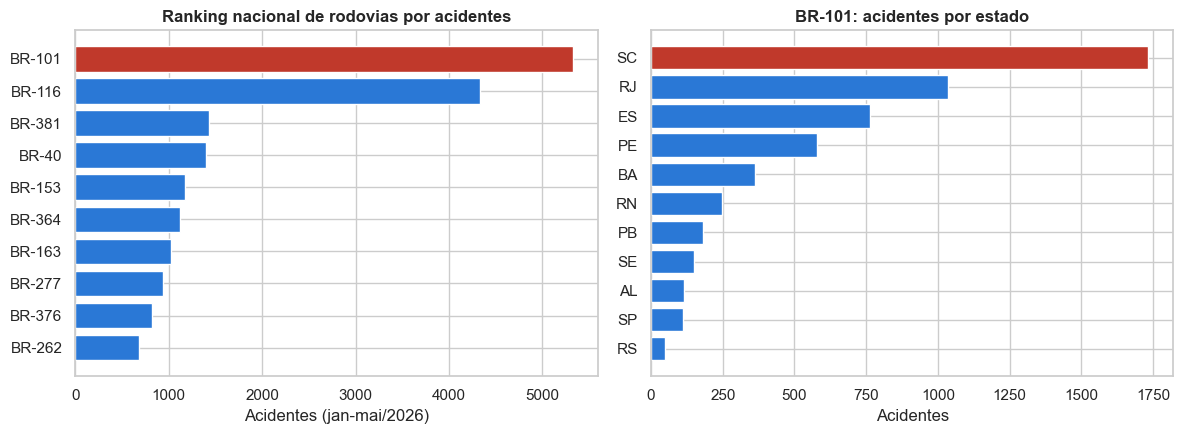

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

labels = [f"BR-{int(b)}" for b in br_rank.index]
cores = [COR_DESTAQUE if b == "BR-101" else COR_BASE for b in labels]
axes[0].barh(labels[::-1], br_rank.values[::-1], color=cores[::-1])
axes[0].set_title("Ranking nacional de rodovias por acidentes", weight="bold")
axes[0].set_xlabel("Acidentes (jan-mai/2026)")

cores_uf = [COR_DESTAQUE if uf == "SC" else COR_BASE for uf in br101_uf.index]
axes[1].barh(br101_uf.index[::-1], br101_uf["acidentes"].values[::-1], color=cores_uf[::-1])
axes[1].set_title("BR-101: acidentes por estado", weight="bold")
axes[1].set_xlabel("Acidentes")

plt.tight_layout()
plt.show()

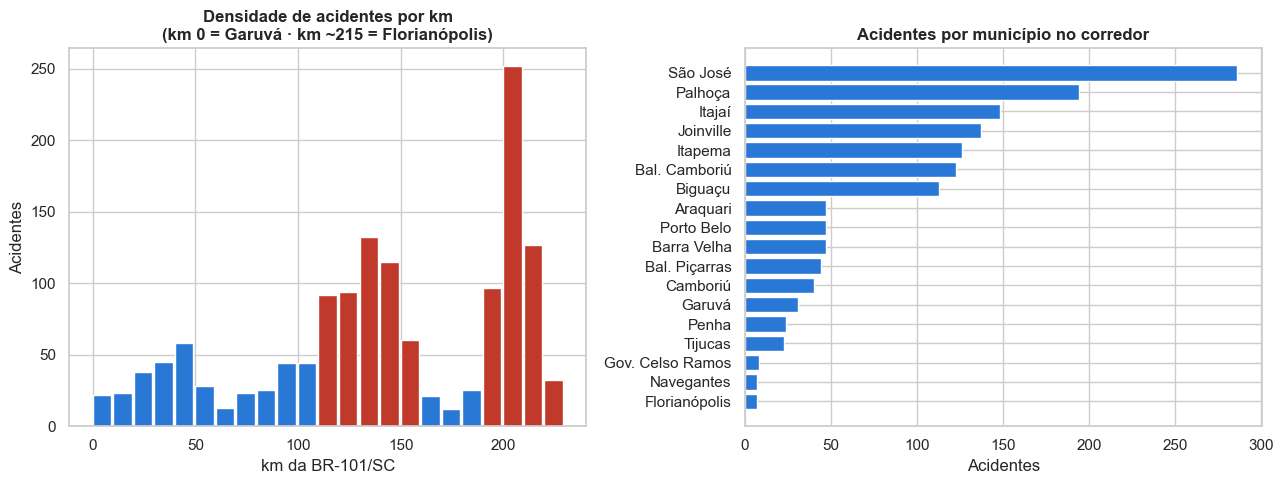

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bins = list(range(0, 231, 10))
km_counts = corredor["km_num"].dropna().groupby(pd.cut(corredor["km_num"].dropna(), bins=bins)).size()
hotspot = [(iv.left >= 190) or (110 <= iv.left < 160) for iv in km_counts.index]
cores_km = [COR_DESTAQUE if h else COR_BASE for h in hotspot]
axes[0].bar([iv.left for iv in km_counts.index], km_counts.values, width=9, color=cores_km, align="edge")
axes[0].set_title("Densidade de acidentes por km\n(km 0 = Garuvá · km ~215 = Florianópolis)", weight="bold")
axes[0].set_xlabel("km da BR-101/SC")
axes[0].set_ylabel("Acidentes")

sev_municipio = (corredor.groupby("municipio")["id"].count()
                  .rename(index=MUNICIPIO_LABEL).sort_values())
axes[1].barh(sev_municipio.index, sev_municipio.values, color=COR_BASE)
axes[1].set_title("Acidentes por município no corredor", weight="bold")
axes[1].set_xlabel("Acidentes")

plt.tight_layout()
plt.show()

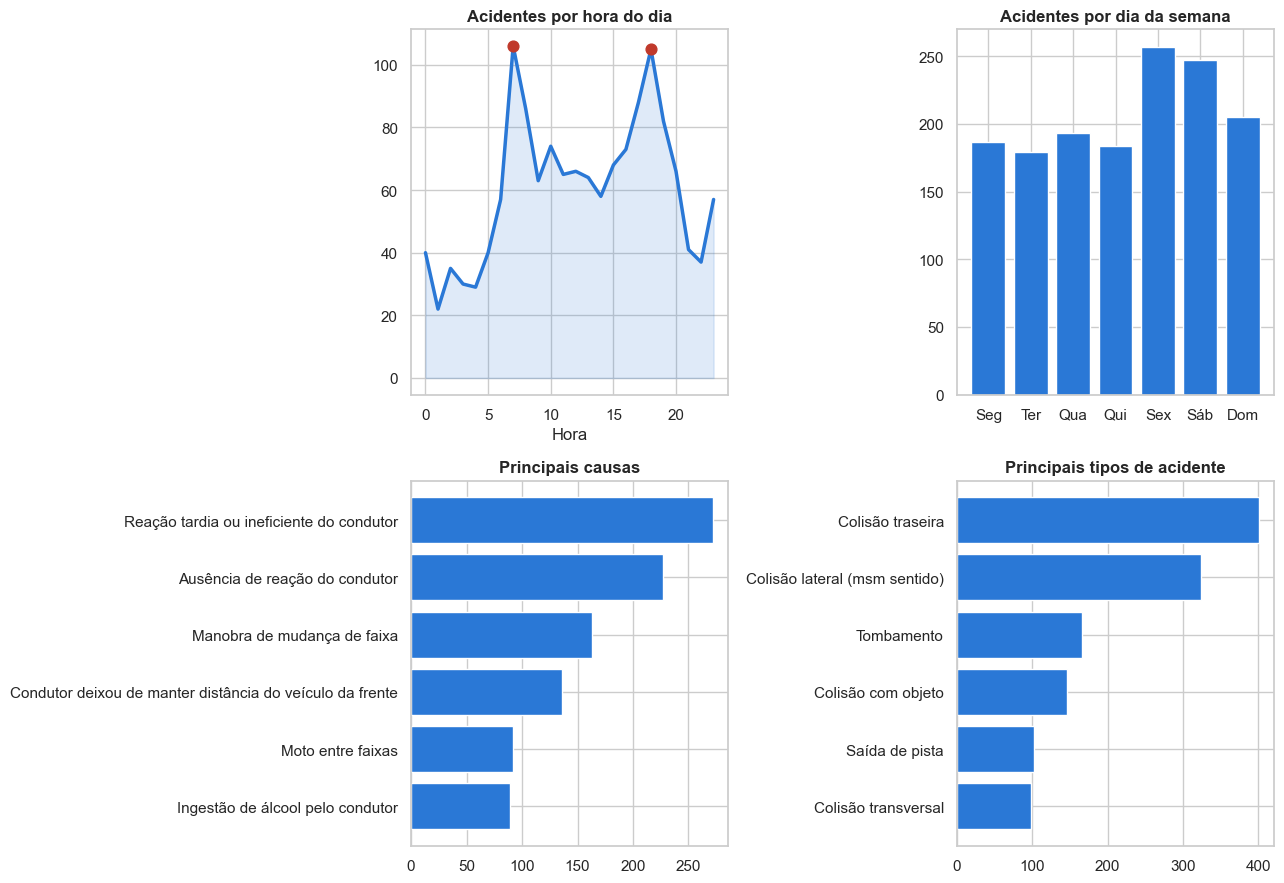

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

hora = pd.to_datetime(corredor["horario"], format="%H:%M:%S", errors="coerce").dt.hour
hora_counts = hora.value_counts().sort_index()
axes[0, 0].plot(hora_counts.index, hora_counts.values, color=COR_BASE, lw=2.5)
axes[0, 0].fill_between(hora_counts.index, hora_counts.values, color=COR_BASE, alpha=0.15)
for h in (7, 18):
    axes[0, 0].scatter([h], [hora_counts[h]], color=COR_DESTAQUE, zorder=5, s=60)
axes[0, 0].set_title("Acidentes por hora do dia", weight="bold")
axes[0, 0].set_xlabel("Hora")

DIA_LABEL = {"segunda-feira": "Seg", "terça-feira": "Ter", "quarta-feira": "Qua",
             "quinta-feira": "Qui", "sexta-feira": "Sex", "sábado": "Sáb", "domingo": "Dom"}
dia_counts = corredor["dia_semana"].value_counts()
dia_out = pd.Series({label: dia_counts.get(d, 0) for d, label in DIA_LABEL.items()})
axes[0, 1].bar(dia_out.index, dia_out.values, color=COR_BASE)
axes[0, 1].set_title("Acidentes por dia da semana", weight="bold")

CAUSA_LABEL = {"Trafegar com motocicleta (ou similar) entre as faixas": "Moto entre faixas"}
causa_counts = corredor["causa_acidente"].value_counts().head(6).rename(index=CAUSA_LABEL)
axes[1, 0].barh(causa_counts.index[::-1], causa_counts.values[::-1], color=COR_BASE)
axes[1, 0].set_title("Principais causas", weight="bold")

TIPO_LABEL = {"Colisão lateral mesmo sentido": "Colisão lateral (msm sentido)",
              "Saída de leito carroçável": "Saída de pista"}
tipo_counts = corredor["tipo_acidente"].value_counts().head(6).rename(index=TIPO_LABEL)
axes[1, 1].barh(tipo_counts.index[::-1], tipo_counts.values[::-1], color=COR_BASE)
axes[1, 1].set_title("Principais tipos de acidente", weight="bold")

plt.tight_layout()
plt.show()

### 4 - Interpretação e plano de ação

**O que os dados mostram.** A BR-101 é a rodovia federal com mais acidentes do Brasil (5.328 em 5
meses, à frente da BR-116), e Santa Catarina concentra mais acidentes na BR-101 do que qualquer
outro estado (1.734). Dentro da BR-101/SC, 83,7% dos acidentes ocorrem exatamente no corredor
Garuvá–Palhoça que a ViaMar vai atravessar, com densidade ~6x maior que o restante da rodovia no
estado — dois hotspots concentram o problema: o acesso a Florianópolis (km 190–220, via São
José/Palhoça) e o eixo turístico Itajaí–Balneário Camboriú–Itapema (km 110–155). O perfil horário,
com picos às 7–8h e 17–19h, e o predomínio de colisões traseiras/laterais (82% em pista já dupla
ou múltipla) apontam para um problema de **capacidade de tráfego**, não de traçado — a letalidade
do corredor é inclusive menor que no restante da rodovia (2,7% vs 3,6%), coerente com velocidades
baixas em trecho congestionado e urbanizado.

**Recomendação de encaminhamento.** Isso não implica automaticamente que a ViaMar "resolve" o
problema — reduzir tráfego não elimina risco, pode só deslocá-lo, e vias novas tendem a induzir
demanda adicional no médio prazo. Para transformar este diagnóstico em um estudo de impacto:

1. **Diagnóstico** — confirmar o traçado oficial da ViaMar e estender a série histórica (2021–2025,
   portal de dados abertos da PRF) para captar sazonalidade completa.
2. **Exposição ao risco** — trazer dado de volume de tráfego (contagens/pedágio da concessionária
   Arteris Litoral Sul) para calcular taxa de acidentes por veículo-km, não só por km de via.
3. **Contexto socioeconômico** — população e frota (IBGE/DENATRAN), movimentação portuária
   (Itajaí, Navegantes, São Francisco do Sul) e sazonalidade turística (Balneário Camboriú).
4. **Modelagem do comparativo** — estimar o desvio de tráfego da BR-101 para a ViaMar por
   segmento e projetar o efeito esperado sobre acidentes nos dois hotspots identificados.
5. **Riscos colaterais** — demanda induzida, segurança viária do novo traçado e tempo de
   licenciamento ambiental (áreas de mangue/restinga no litoral).
6. **Entrega** — cenários conservador/base/otimista, não um número único, revisados com
   DNIT/DEINFRA, a concessionária e as prefeituras do corredor.